# Fuel prediction with chronological energy dispatch

How many days until fuel drops to the refueling threshold, given a site's solar,
battery, load and generator?

The simulation walks the clock from midnight in 15-minute steps, splitting a step
further whenever equipment changes state. In each step solar serves the load
first, surplus charges the battery, the battery covers what solar cannot, and the
generator starts and stops on SOC hysteresis. The daily tables below are
aggregates of those steps.

Solar and load profiles repeat every day, so a result describes the modeled
scenario, not a weather forecast.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from fuelsim import SimulationConfig, run_simulation
from fuelsim.plotting import plot_daily_energy, plot_intraday, plot_trajectory

pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

## 1. Inputs

Site measurements and equipment ratings first, then the simulation assumptions.

The baseline carries measured 24-hour load and solar profiles. When those are
supplied they replace the scalar model; otherwise `solar_hours_per_day` sets the
daily yield and `solar_window_hours` sets how that energy spreads across the day.

Charge and discharge efficiency are set to 95% each (90.25% round trip) until
equipment data is available, and battery power limits are left unset so no limit
is modeled. The generator burns a constant L/h while running; supply an idle rate
and consumption interpolates linearly between idle and rated output.

In [2]:
baseline = SimulationConfig(
    # Saved site measurements
    battery_soc_pct=100.0,
    fuel_level_l=100.0,
    solar_capacity_kw=3.2,
    current_load_kw=0.7,

    # Saved equipment configuration
    battery_capacity_kwh=30.0,
    gen_start_soc_pct=20.0,
    gen_stop_soc_pct=80.0,
    gen_rated_kw=5.0,
    gen_fuel_lph=2.5,
    fuel_threshold_l=20.0,

    # Chronological simulation assumptions
    timestep_minutes=15,
    solar_hours_per_day=5.0,       # daily yield = 3.2 kW x 5 h = 16 kWh
    solar_window_hours=5.0,       # idealized full-power daylight block
    solar_start_hour=9.5,         # 09:30 to 14:30
    hourly_load_kw=[
    0.4426166667,
    0.4433333333,
    0.4293333333,
    0.4199694444,
    0.4326444444,
    0.4432611111,
    0.4589166667,
    0.4650388889,
    0.4721527778,
    0.4745027778,
    0.4670138889,
    0.4645527778,
    0.4663388889,
    0.4640388889,
    0.4539277778,
    0.4447833333,
    0.4318611111,
    0.4417,
    0.4455916667,
    0.4449583333,
    0.4480888889,
    0.4444194444,
    0.4352694444,
    0.43632493
],          # optional 24-value kW profile
    hourly_solar_kw=[
    0.0,
    0.0,
    0.0,
    0.05385,
    0.3249222,
    0.8015583,
    1.251933,
    1.313639,
    1.396461,
    1.4253,
    1.154072,
    0.8738639,
    0.8124056,
    0.7079889,
    0.5202833,
    0.1175,
    0.003277778,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0
],         # optional 24-value kW profile
    daily_solar_factors=(1.0,),   # repeats this assumed solar day
    battery_charge_efficiency=0.95,
    battery_discharge_efficiency=0.95,
    battery_max_charge_kw=None,   # unknown rating: no modeled power limit
    battery_max_discharge_kw=None,
    gen_idle_fuel_lph=None,       # None: constant L/h while running
    max_days=300,
    report_horizon_days=30,
)

print(f"Daily load: {baseline.daily_load_kwh:.2f} kWh")
print(f"Unscaled daily solar: {baseline.daily_solar_kwh:.2f} kWh")
print(f"Generator starts at {baseline.gen_start_soc_pct:g}% SOC and stops at "
      f"{baseline.gen_stop_soc_pct:g}% SOC.")
print("Charge/discharge efficiencies: assumed 95% each; battery power ratings unspecified.")


Daily load: 10.77 kWh
Unscaled daily solar: 10.76 kWh
Generator starts at 20% SOC and stops at 80% SOC.
Charge/discharge efficiencies: assumed 95% each; battery power ratings unspecified.


## 2. Fuel prediction

Run the baseline and report the day fuel reaches the threshold. The display is
capped at 30 days, and the summary gives the actual horizon when the threshold
falls beyond it.

In [3]:
result = run_simulation(baseline)
print(result.summary())
print(f"Threshold day within this scenario: {result.days_until_threshold}")
print(f"Modeled fuel consumption: {sum(day.fuel_used_l for day in result.days):.2f} L")
print(f"Modeled unmet demand: {sum(day.unserved_load_kwh for day in result.days):.3f} kWh")

Fuel reaches the 20 L threshold in >30 days (from 100 L, hourly load profile, solar capacity 3.2 kW); modeled fuel consumption 81.5891 L.
Threshold day within this scenario: 266
Modeled fuel consumption: 81.59 L
Modeled unmet demand: 0.000 kWh


## 3. Daily energy flows

One row per simulated day. Solar and generator charging columns are input energy
before charging losses; battery discharge is energy delivered to the load, after
discharge losses. Net battery change is positive when the day ends with more
stored energy. Minimum SOC exposes overnight depletion that the end-of-day value
hides.

In [4]:
daily = result.to_frame()
daily["battery_net_change_kwh"] = daily["battery_end_kwh"] - daily["battery_start_kwh"]
daily[[
    "day", "soc_start_pct", "soc_min_pct", "soc_end_pct",
    "solar_to_load_kwh", "solar_to_battery_kwh", "solar_curtailed_kwh",
    "battery_to_load_kwh", "battery_net_change_kwh",
    "battery_charge_loss_kwh", "battery_discharge_loss_kwh",
    "generator_to_load_kwh", "generator_to_battery_kwh",
    "generator_hours", "fuel_used_l", "fuel_end_l", "unserved_load_kwh",
]]

,day,soc_start_pct,soc_min_pct,soc_end_pct,solar_to_load_kwh,solar_to_battery_kwh,solar_curtailed_kwh,battery_to_load_kwh,battery_net_change_kwh,battery_charge_loss_kwh,battery_discharge_loss_kwh,generator_to_load_kwh,generator_to_battery_kwh,generator_hours,fuel_used_l,fuel_end_l,unserved_load_kwh
0,1,100.00,86.48,86.48,5.13,1.98,3.65,5.64,-4.05,0.10,0.30,0.00,0.00,0.00,0.00,100.00,0.00
1,2,86.48,80.21,84.51,5.13,5.63,0.00,5.64,-0.59,0.28,0.30,0.00,0.00,0.00,0.00,100.00,0.00
2,3,84.51,78.23,82.54,5.13,5.63,0.00,5.64,-0.59,0.28,0.30,0.00,0.00,0.00,0.00,100.00,0.00
3,4,82.54,76.26,80.56,5.13,5.63,0.00,5.64,-0.59,0.28,0.30,0.00,0.00,0.00,0.00,100.00,0.00
4,5,80.56,74.29,78.59,5.13,5.63,0.00,5.64,-0.59,0.28,0.30,0.00,0.00,0.00,0.00,100.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,262,32.48,26.20,30.51,5.13,5.63,0.00,5.64,-0.59,0.28,0.30,0.00,0.00,0.00,0.00,27.67,0.00
262,263,30.51,24.23,28.54,5.13,5.63,0.00,5.64,-0.59,0.28,0.30,0.00,0.00,0.00,0.00,27.67,0.00
263,264,28.54,22.26,26.56,5.13,5.63,0.00,5.64,-0.59,0.28,0.30,0.00,0.00,0.00,0.00,27.67,0.00
264,265,26.56,20.28,24.59,5.13,5.63,0.00,5.64,-0.59,0.28,0.30,0.00,0.00,0.00,0.00,27.67,0.00


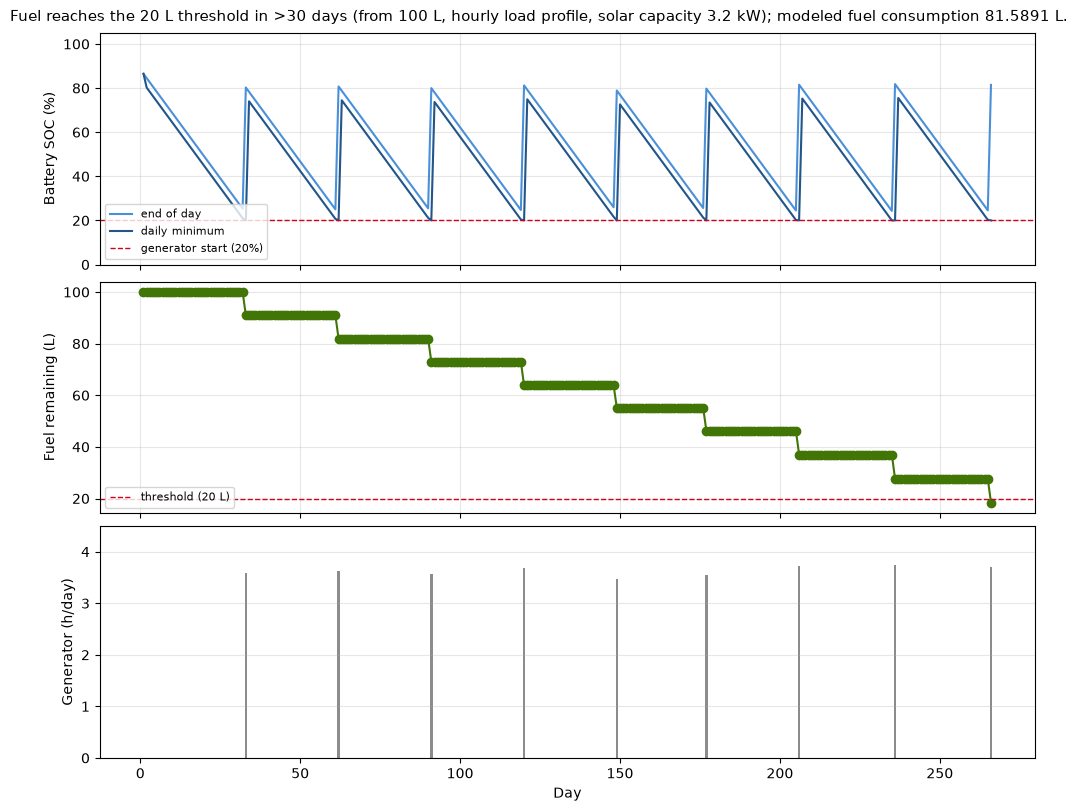

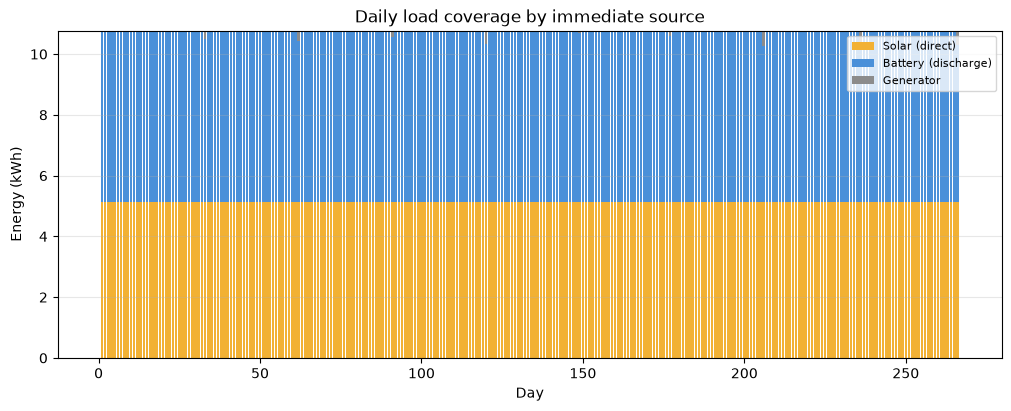

In [5]:
fig = plot_trajectory(result)
plt.show()
plt.close(fig)
fig = plot_daily_energy(result)
plt.show()
plt.close(fig)

## 4. Intraday day/night sequence

The intraday charts show which source serves the load at each moment, SOC rising
as the battery charges, and the generator's actual run intervals, including
starts and stops that fall inside a 15-minute step. Solar never serves load
outside its production window.

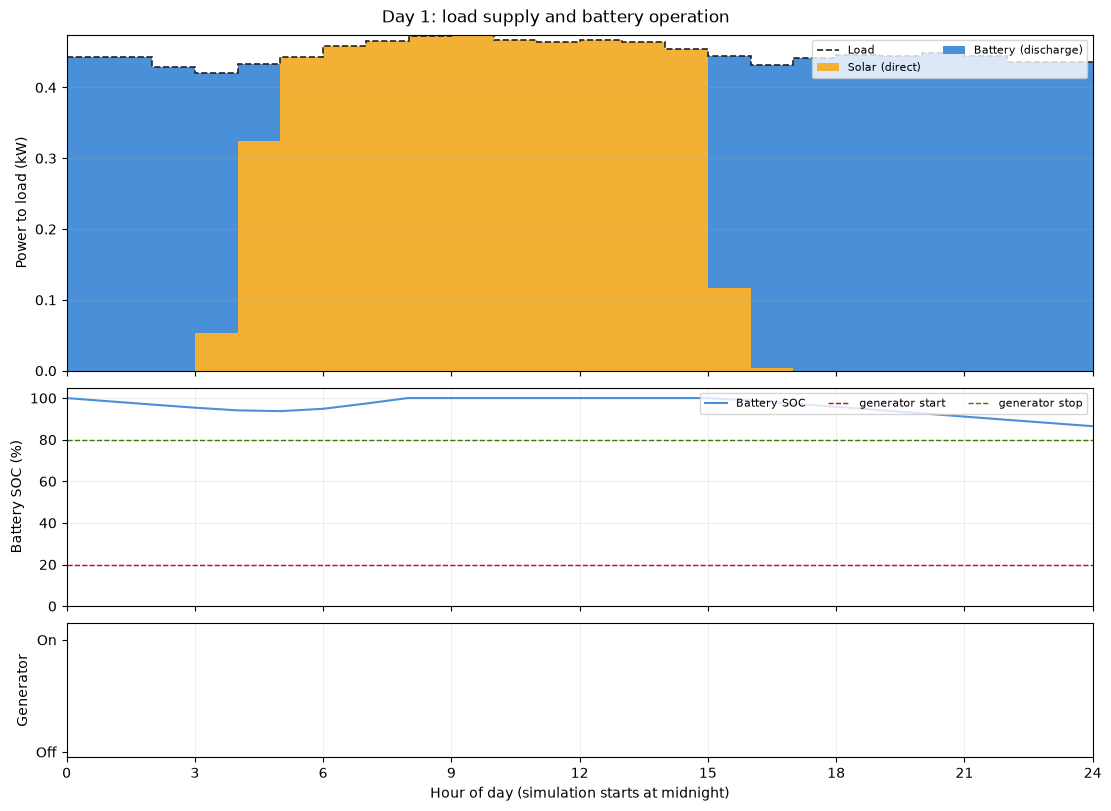

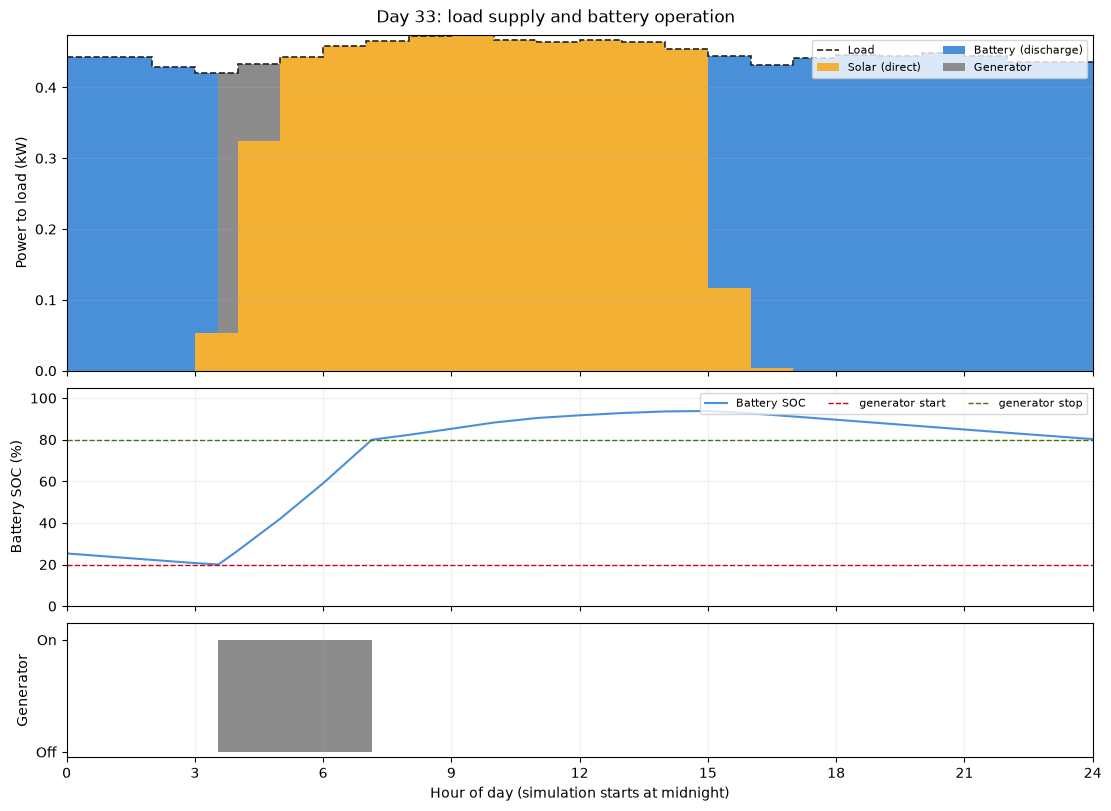

In [6]:
fig = plot_intraday(result, day=1)
plt.show()
plt.close(fig)

first_generator_day = next((day.day for day in result.days if day.generator_hours > 0), None)
if first_generator_day is not None and first_generator_day != 1:
    fig = plot_intraday(result, day=first_generator_day)
    plt.show()
    plt.close(fig)

## 5. Conservation checks and load sensitivity

The checks run on the inputs configured above, with one variation each for zero
solar, a power-limited battery, and a load scaled past the generator's 5 kW
rating. Each scenario is checked for load, battery, solar and fuel balance, and
for SOC staying inside capacity.

A daily balance does not prove correct timing, so the regression tests separately
cover nighttime supply, fractional generator cycles, power limits, and state
carried across midnight.

The sweep that follows scales the measured load profile instead of replacing it
with a flat demand, so the shape of the day is preserved as total demand rises.


In [7]:
def check_scenario(label, config):
    run = run_simulation(config)
    frame = run.to_frame()
    served = (frame["solar_to_load_kwh"] + frame["battery_to_load_kwh"]
              + frame["generator_to_load_kwh"] + frame["unserved_load_kwh"])
    charged = (frame["solar_to_battery_kwh"] + frame["generator_to_battery_kwh"]) * config.battery_charge_efficiency
    withdrawn = frame["battery_to_load_kwh"] / config.battery_discharge_efficiency
    return {
        "scenario": label,
        "load balances": bool(np.allclose(served, frame["load_kwh"], atol=1e-8)),
        "battery balances": bool(np.allclose(frame["battery_end_kwh"] - frame["battery_start_kwh"], charged - withdrawn, atol=1e-8)),
        "solar balances": bool(np.allclose(frame["solar_kwh"], frame["solar_to_load_kwh"] + frame["solar_to_battery_kwh"] + frame["solar_curtailed_kwh"], atol=1e-8)),
        "fuel balances": bool(np.allclose(frame["fuel_start_l"] - frame["fuel_used_l"], frame["fuel_end_l"], atol=1e-8)),
        "SOC within capacity": bool(frame["soc_min_pct"].ge(-1e-8).all() and frame["soc_max_pct"].le(config.max_soc_pct + 1e-8).all()),
        "unmet load kWh": frame["unserved_load_kwh"].sum(),
    }


def scaled_load(factor, **changes):
    """Baseline with the measured load profile scaled by `factor`."""
    return baseline.with_changes(
        hourly_load_kw=tuple(kw * factor for kw in baseline.hourly_load_kw),
        **changes,
    )


checks = pd.DataFrame([
    check_scenario("measured inputs", baseline),
    check_scenario("no solar", baseline.with_changes(hourly_solar_kw=(0.0,) * 24)),
    check_scenario("power constrained battery", baseline.with_changes(
        battery_max_charge_kw=0.3, battery_max_discharge_kw=0.2)),
    check_scenario("load above generator rating", scaled_load(12.0)),
]).set_index("scenario")
assert checks[["load balances", "battery balances", "solar balances", "fuel balances", "SOC within capacity"]].all().all()
checks


,load balances,battery balances,solar balances,fuel balances,SOC within capacity,unmet load kWh
scenario,,,,,,
measured inputs,True,True,True,True,True,0.00
no solar,True,True,True,True,True,0.00
power constrained battery,True,True,True,True,True,0.00
load above generator rating,True,True,True,True,True,15.12


In [8]:
def scenario_row(label, config):
    run = run_simulation(config)
    frame = run.to_frame()
    return {
        "scenario": label,
        "threshold day": run.days_until_threshold,
        "display": run.days_display,
        "simulated days": len(run.days),
        "fuel used L": frame["fuel_used_l"].sum(),
        "generator h": frame["generator_hours"].sum(),
        "minimum SOC %": frame["soc_min_pct"].min(),
        "battery output kWh/day": frame["battery_to_load_kwh"].mean(),
        "unmet load kWh": frame["unserved_load_kwh"].sum(),
    }


load_sweep = pd.DataFrame([
    scenario_row(f"x{factor:g} ({baseline.daily_load_kwh * factor:.1f} kWh/day)", scaled_load(factor))
    for factor in [0.6, 0.8, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0]
]).set_index("scenario")
load_sweep


,threshold day,display,simulated days,fuel used L,generator h,minimum SOC %,battery output kWh/day,unmet load kWh
scenario,,,,,,,,
x0.6 (6.5 kWh/day),NaN,>30 days,300,0.00,0.00,88.60,3.25,0.00
x0.8 (8.6 kWh/day),NaN,>30 days,300,0.00,0.00,84.52,4.41,0.00
x1 (10.8 kWh/day),266.00,>30 days,266,81.59,32.64,20.00,5.63,0.00
x1.25 (13.5 kWh/day),49.00,>30 days,49,82.01,32.80,20.00,6.94,0.00
x1.5 (16.2 kWh/day),29.00,29 days,29,86.75,34.70,20.00,8.57,0.00
x2 (21.5 kWh/day),16.00,16 days,16,91.52,36.61,20.00,10.68,0.00
x2.5 (26.9 kWh/day),10.00,10 days,10,82.27,32.91,20.00,13.68,0.00
x3 (32.3 kWh/day),8.00,8 days,8,82.41,32.96,20.00,17.53,0.00
